[APRIL 28] RESULTS CODE V4

In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolours
from IPython.display import display
from google.colab import files
pd.set_option('display.max_rows', None)

In [ ]:
homomorphic = pd.read_csv('/kd_all_seeds_results.csv')
heterogenous = pd.read_csv('/kd_mismatch_all_seeds.csv')

# 00 Main Analysis - Pairwirse

## Plot Generation

In [ ]:
def plot_segment_accs(teacher_name):
    segment = homomorphic[homomorphic['teacher_name'] == teacher_name]
    jitter = np.random.uniform(-0.15, 0.15, size=len(segment))

    scatter = plt.scatter(
        segment['distill_temperature'] + jitter,
        segment['student_accuracy'],
        c=segment['alpha'],
        cmap='Greys',
        edgecolor='black',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Alpha Value')

    plt.ylabel("Student Accuracy")
    plt.xlabel("Distillation Temperature")
    plt.title(teacher_name)
    # plt.savefig(f"{teacher_name}_accuracy_plot.png", dpi=300, bbox_inches='tight')
    # files.download(f"{teacher_name}_accuracy_plot.png")
    plt.show()
def plot_segment_ece(teacher_name):
    segment = homomorphic[homomorphic['teacher_name'] == teacher_name]
    jitter = np.random.uniform(-0.15, 0.15, size=len(segment))

    scatter = plt.scatter(
        segment['distill_temperature'] + jitter,
        segment['student_ece'],
        c=segment['alpha'],
        cmap='Greys',
        edgecolor='black',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Alpha Value')

    plt.ylabel("Student ECE")
    plt.xlabel("Distillation Temperature")
    plt.title(teacher_name)
    # plt.savefig(f"{teacher_name}_ece_plot.png", dpi=300, bbox_inches='tight')
    # files.download(f"{teacher_name}_ece_plot.png")
    plt.show()

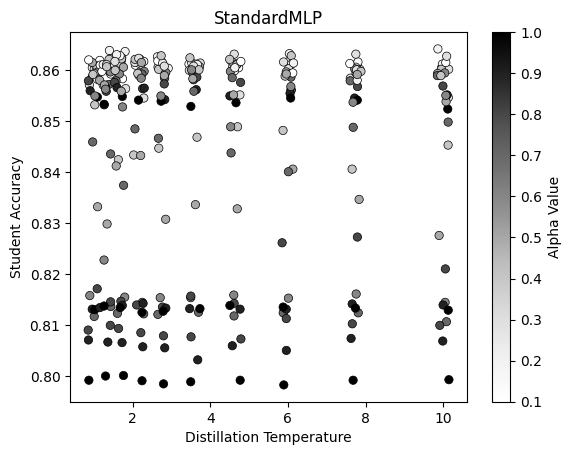

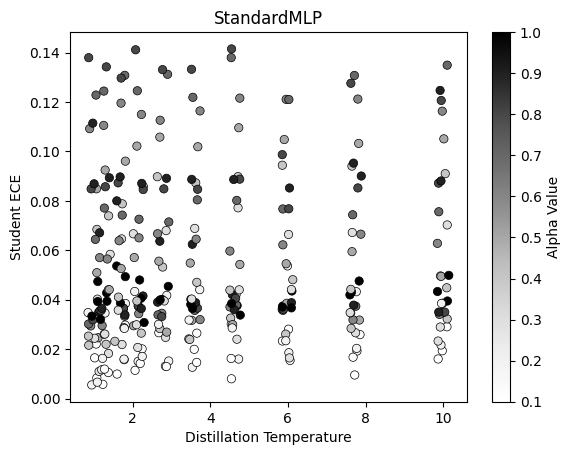

In [ ]:
plot_segment_accs('StandardMLP')
plot_segment_ece('StandardMLP')

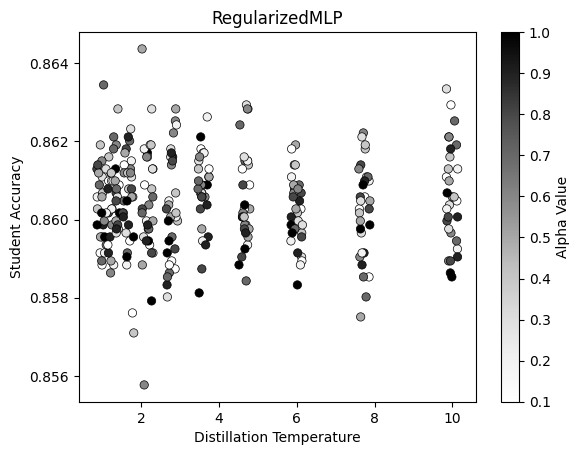

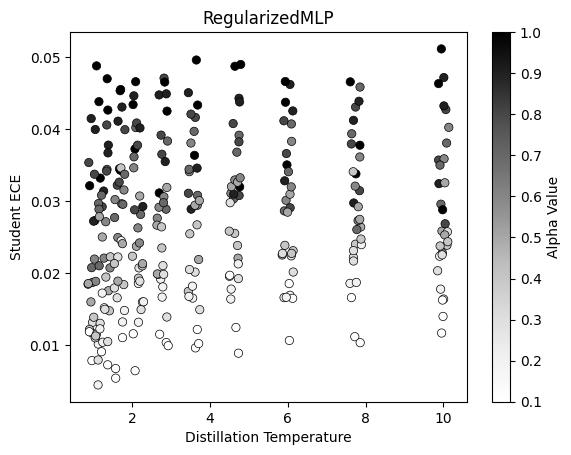

In [ ]:
plot_segment_accs('RegularizedMLP')
plot_segment_ece('RegularizedMLP')

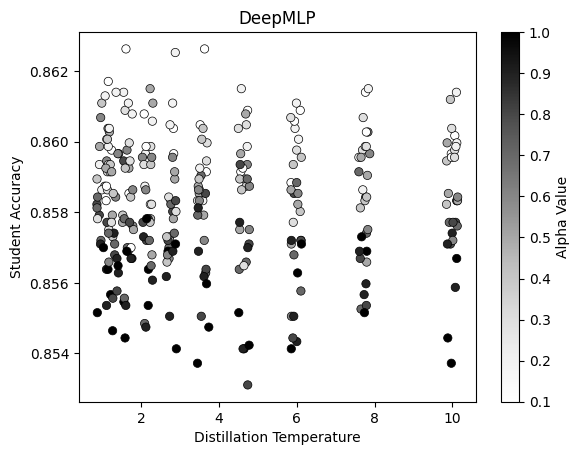

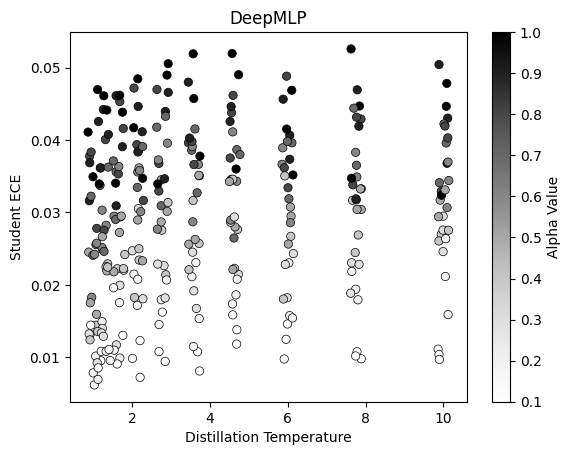

In [ ]:
plot_segment_accs('DeepMLP')
plot_segment_ece('DeepMLP')

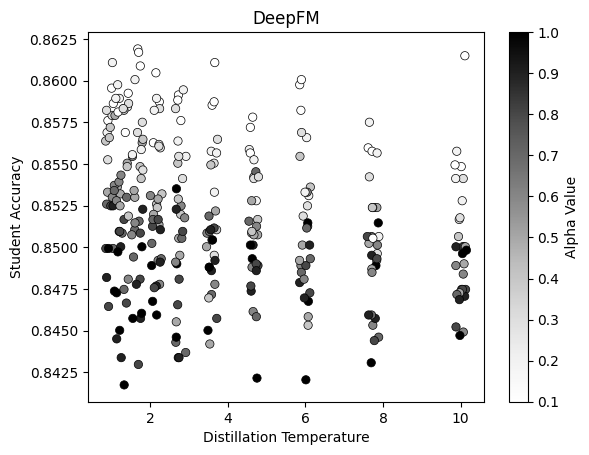

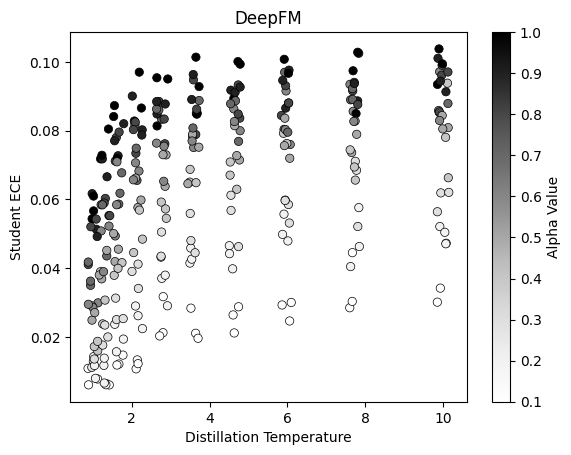

In [ ]:
plot_segment_accs('DeepFM')
plot_segment_ece('DeepFM')

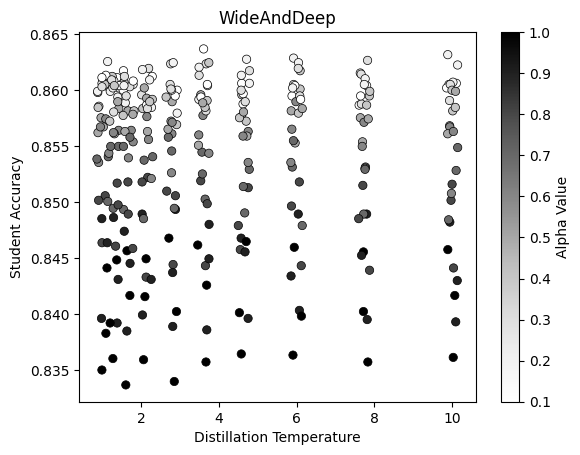

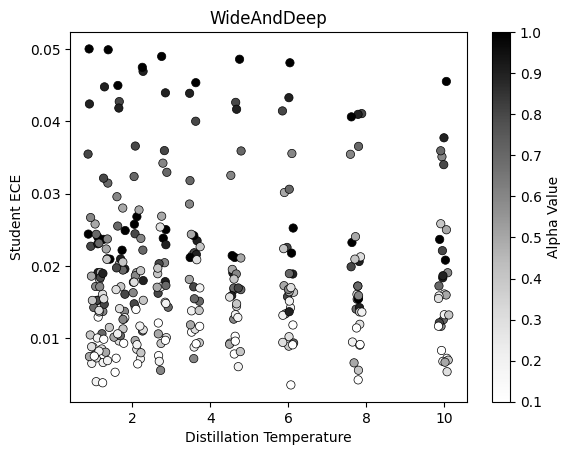

In [ ]:
plot_segment_accs('WideAndDeep')
plot_segment_ece('WideAndDeep')

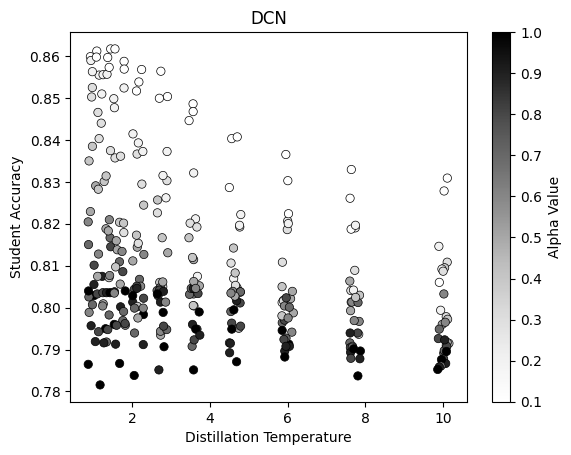

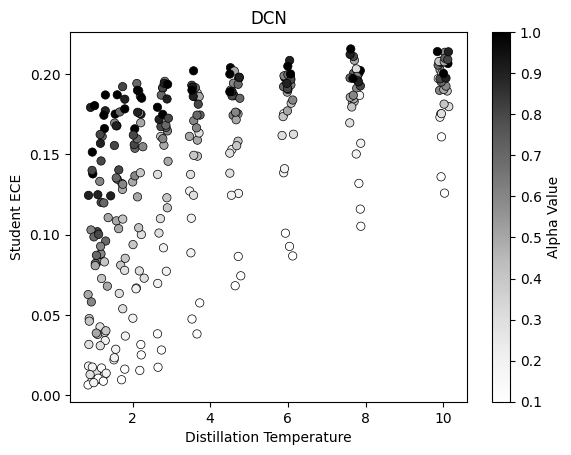

In [ ]:
plot_segment_accs('DCN')
plot_segment_ece('DCN')

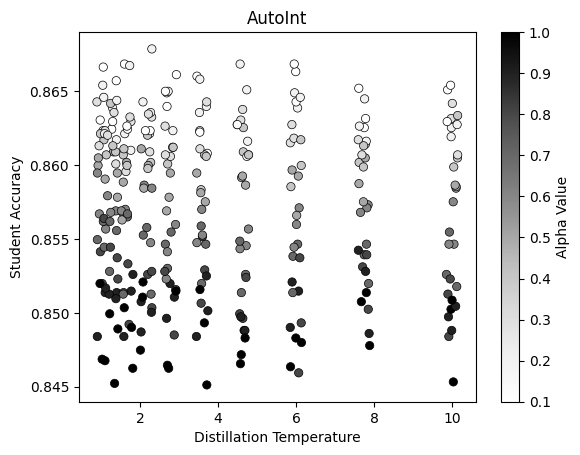

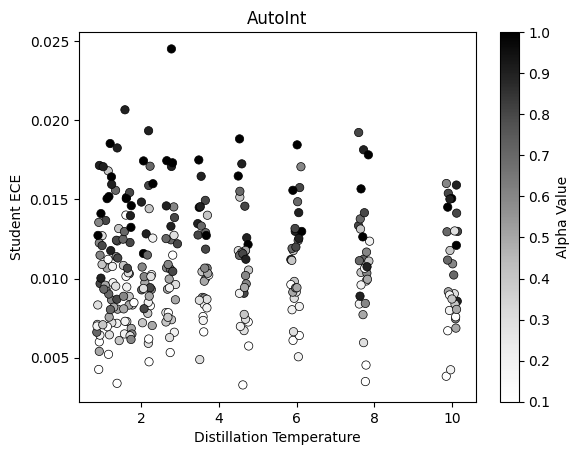

In [ ]:
plot_segment_accs('AutoInt')
plot_segment_ece('AutoInt')

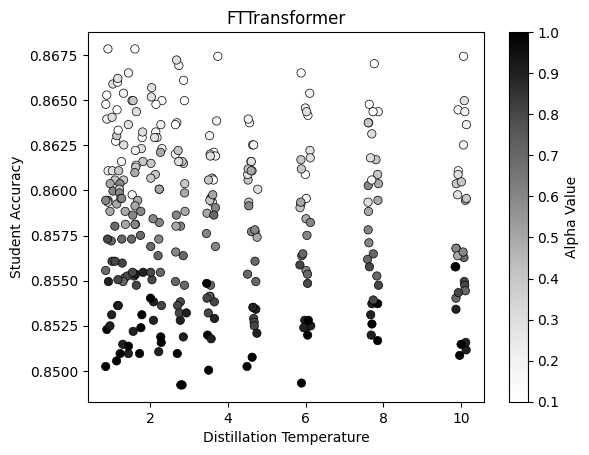

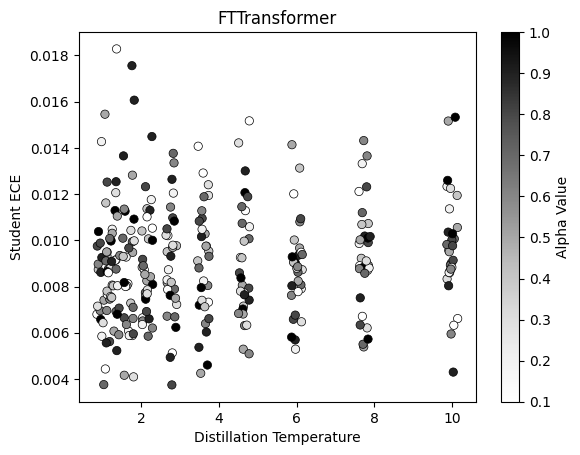

In [ ]:
plot_segment_accs('FTTransformer')
plot_segment_ece('FTTransformer')

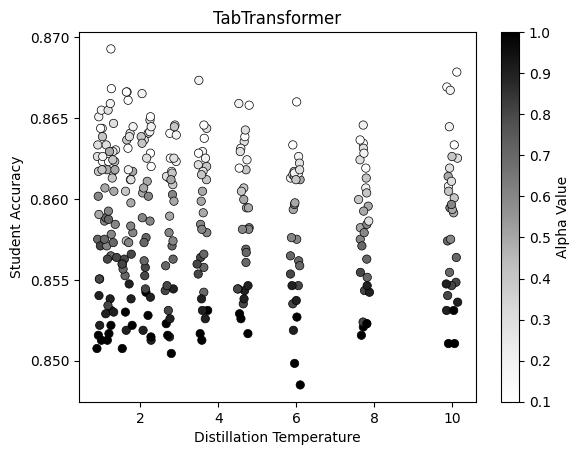

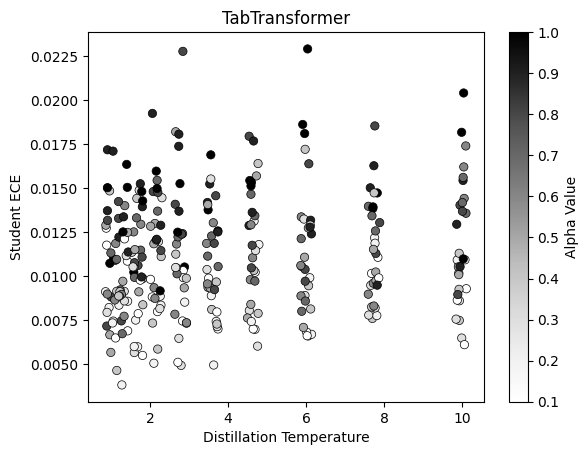

In [ ]:
plot_segment_accs('TabTransformer')
plot_segment_ece('TabTransformer')

## Accuracy and Calibration Analysis

In [ ]:
pairwise_accuracy_stats = homomorphic.groupby('teacher_name')['student_accuracy'].agg(
    min_accuracy ='min',
    max_accuracy='max',
    accuracy_difference =lambda x: x.max() - x.min(),
    mean_accuracy = 'mean',
    standard_deviation_accuracy = 'std'
)
display(pairwise_accuracy_stats)

,min_accuracy,max_accuracy,accuracy_difference,mean_accuracy,standard_deviation_accuracy
teacher_name,,,,,
AutoInt,0.845122,0.867847,0.022725,0.857061,0.005625
DCN,0.781554,0.861705,0.080151,0.810357,0.019695
DeepFM,0.841744,0.861910,0.020166,0.851766,0.004416
DeepMLP,0.853107,0.862627,0.009520,0.858180,0.001855
FTTransformer,0.849217,0.867847,0.018630,0.858386,0.004504
RegularizedMLP,0.855768,0.864367,0.008599,0.860431,0.001196
StandardMLP,0.798342,0.864162,0.065820,0.844679,0.021414
TabTransformer,0.848500,0.869280,0.020780,0.858756,0.004433
WideAndDeep,0.833657,0.863650,0.029993,0.853893,0.007340


In [ ]:
pairwise_calibration_stats = homomorphic.groupby('teacher_name')['student_ece'].agg(
    min_ece ='min',
    max_ece ='max',
    ece_difference = lambda x: x.max() - x.min(),
    mean_ece = 'mean',
    standard_deviation_ece = 'std'
)
display(pairwise_calibration_stats)

,min_ece,max_ece,ece_difference,mean_ece,standard_deviation_ece
teacher_name,,,,,
AutoInt,0.003283,0.024512,0.021229,0.010861,0.003538
DCN,0.006437,0.215523,0.209086,0.142217,0.059354
DeepFM,0.006046,0.103792,0.097746,0.060977,0.026703
DeepMLP,0.006191,0.052579,0.046388,0.029093,0.011407
FTTransformer,0.003744,0.018277,0.014533,0.009032,0.002467
RegularizedMLP,0.004417,0.051183,0.046766,0.027347,0.010913
StandardMLP,0.005528,0.141466,0.135938,0.053859,0.033945
TabTransformer,0.003838,0.022916,0.019078,0.011178,0.003323
WideAndDeep,0.003541,0.050031,0.046490,0.019048,0.010423


## Optimal Temperature

In [ ]:
df_accs = homomorphic.groupby(['teacher_name','distill_temperature','alpha'])[['student_accuracy','student_ece']].mean()

def get_optimal_params(group):
    threshold = group['student_accuracy'].max() - 0.01
    candidates = group[group['student_accuracy'] >= threshold]
    return candidates.loc[candidates['student_ece'].idxmin()]

optimal_temperature_dynamic_choice= df_accs.reset_index().groupby('teacher_name').apply(get_optimal_params, include_groups=False)

display(optimal_temperature_dynamic_choice)

,distill_temperature,alpha,student_accuracy,student_ece
teacher_name,,,,
AutoInt,4.642,0.1,0.862012,0.005428
DCN,1.000,0.1,0.860272,0.008363
DeepFM,1.292,0.1,0.858089,0.006170
DeepMLP,1.000,0.2,0.859760,0.008323
FTTransformer,4.642,0.6,0.858225,0.006079
RegularizedMLP,1.668,0.1,0.859487,0.007685
StandardMLP,1.292,0.1,0.860886,0.009409
TabTransformer,1.668,0.2,0.864299,0.006512
WideAndDeep,1.000,0.2,0.860989,0.006851


# 01 Secondary Analysis - By Architecture

## Plot Generation

In [ ]:
def plot_segment_accs_ByArchitecture(name):
    segment = homomorphic[homomorphic['teacher_category'] == name]

    jitter = np.random.uniform(-0.15, 0.15, size=len(segment))

    scatter = plt.scatter(
        segment['distill_temperature'] + jitter,
        segment['student_accuracy'],
        c=segment['alpha'],
        cmap='Greys',
        edgecolor='black',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Alpha Value')

    plt.ylabel("Student Accuracy")
    plt.xlabel("Distillation Temperature")
    plt.title(name)

    filename = f"{name}_accuracy_plot.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # files.download(filename)

    plt.show()

def plot_segment_ece_ByArchitecture(name):
    segment = homomorphic[homomorphic['teacher_category'] == name]

    jitter = np.random.uniform(-0.15, 0.15, size=len(segment))

    scatter = plt.scatter(
        segment['distill_temperature'] + jitter,
        segment['student_ece'],
        c=segment['alpha'],
        cmap='Greys',
        edgecolor='black',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Alpha Value')

    plt.ylabel("Student ECE")
    plt.xlabel("Distillation Temperature")
    plt.title(name)

    filename = f"{name}_ece_plot.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # files.download(filename)

    plt.show()

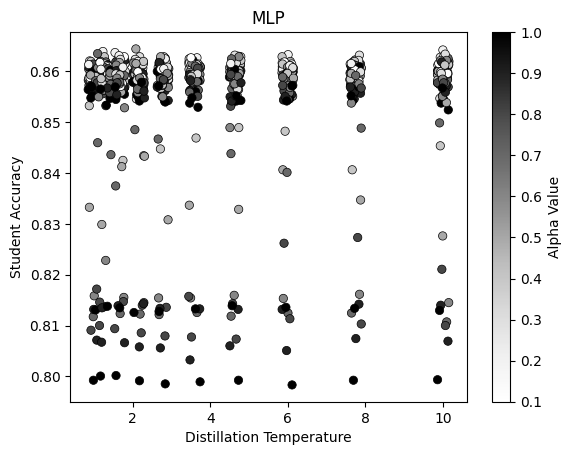

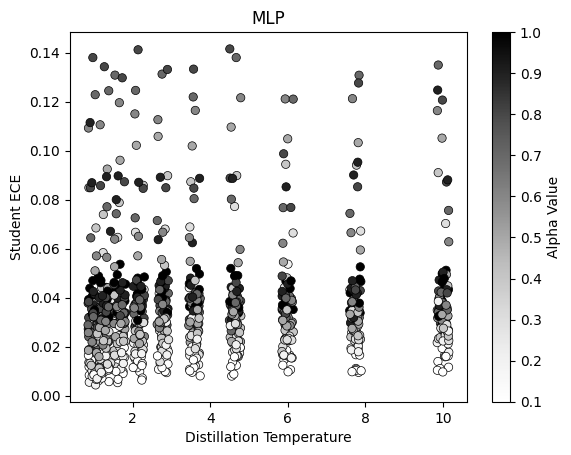

In [ ]:
plot_segment_accs_ByArchitecture ('MLP')
plot_segment_ece_ByArchitecture ('MLP')

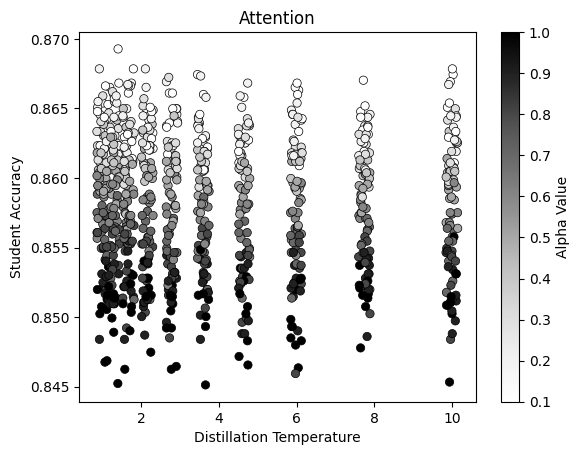

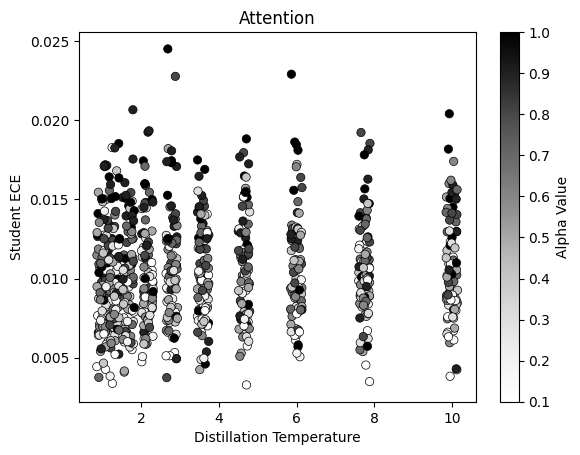

In [ ]:
plot_segment_accs_ByArchitecture ('Attention')
plot_segment_ece_ByArchitecture ('Attention')

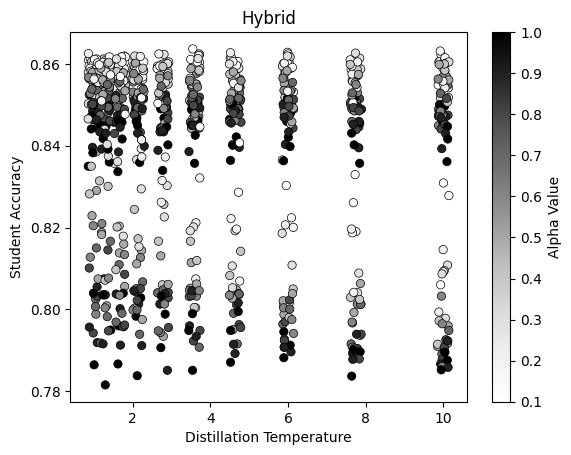

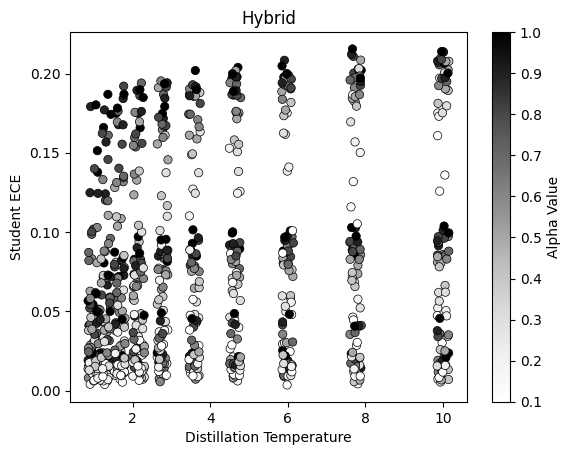

In [ ]:
plot_segment_accs_ByArchitecture ('Hybrid')
plot_segment_ece_ByArchitecture ('Hybrid')

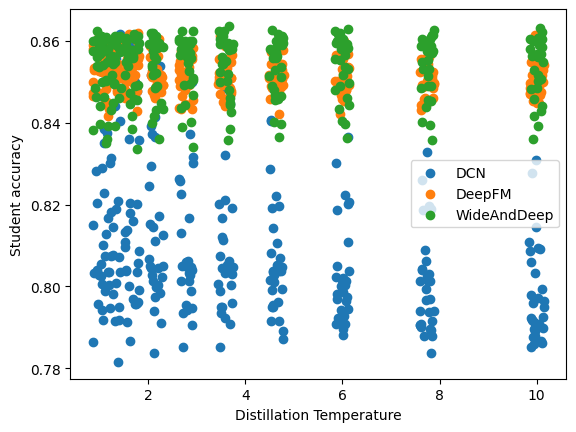

In [ ]:
import numpy as np
segment = homomorphic[homomorphic['teacher_category']=='Hybrid']
Hybrid = ['DCN','DeepFM','WideAndDeep']


segment = segment.reset_index()
for teacher in Hybrid:
  partition = segment[segment['teacher_name']==teacher]
  jitter = np.random.uniform(-0.15, 0.15, size=len(partition))
  plt.scatter(partition['distill_temperature']+jitter,partition['student_accuracy'], label = teacher)

plt.ylabel("Student accuracy")
plt.xlabel("Distillation Temperature")
# plt.title()
plt.legend()
plt.show()

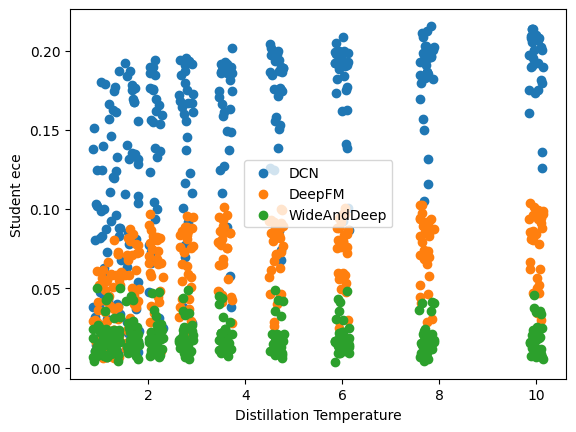

In [ ]:
import numpy as np
segment = homomorphic[homomorphic['teacher_category']=='Hybrid']
Hybrid = ['DCN','DeepFM','WideAndDeep']


segment = segment.reset_index()
for teacher in Hybrid:
  partition = segment[segment['teacher_name']==teacher]
  jitter = np.random.uniform(-0.15, 0.15, size=len(partition))
  plt.scatter(partition['distill_temperature']+jitter,partition['student_ece'], label = teacher)

plt.ylabel("Student ece")
plt.xlabel("Distillation Temperature")
# plt.title()
plt.legend()
plt.show()

## Accuracy and Calibration Analysis

In [ ]:
pairwise_accuracy_stats_ByArchitecture = homomorphic.groupby('teacher_category')['student_accuracy'].agg(
    min_accuracy ='min',
    max_accuracy='max',
    accuracy_difference =lambda x: x.max() - x.min(),
    mean_accuracy = 'mean',
    standard_deviation_accuracy = 'std'
)
display(pairwise_accuracy_stats_ByArchitecture)

,min_accuracy,max_accuracy,accuracy_difference,mean_accuracy,standard_deviation_accuracy
teacher_category,,,,,
Attention,0.845122,0.869280,0.024158,0.858068,0.004933
Hybrid,0.781554,0.863650,0.082096,0.838672,0.023569
MLP,0.798342,0.864367,0.066025,0.854430,0.014233


In [ ]:
pairwise_calibration_stats_ByArchitecture = homomorphic.groupby('teacher_category')['student_ece'].agg(
    min_ece ='min',
    max_ece ='max',
    ece_difference = lambda x: x.max() - x.min(),
    mean_ece = 'mean',
    standard_deviation_ece = 'std'
)
pairwise_calibration_stats_ByArchitecture

,min_ece,max_ece,ece_difference,mean_ece,standard_deviation_ece
teacher_category,,,,,
Attention,0.003283,0.024512,0.021229,0.010357,0.003279
Hybrid,0.003541,0.215523,0.211982,0.074081,0.063735
MLP,0.004417,0.141466,0.137049,0.036767,0.024757


## Optimal Temperature

In [ ]:
df_accs = homomorphic.groupby(['teacher_category','teacher_name','distill_temperature','alpha'])[['student_accuracy','student_ece']].mean()

def get_optimal_params(group):
    threshold = group['student_accuracy'].max() - 0.01
    candidates = group[group['student_accuracy'] >= threshold]
    return candidates.loc[candidates['student_ece'].idxmin()]

optimal_temperature_dynamic_choice_ByArchitecture= df_accs.reset_index().groupby('teacher_category').apply(get_optimal_params, include_groups=False)

display(optimal_temperature_dynamic_choice_ByArchitecture)

,teacher_name,distill_temperature,alpha,student_accuracy,student_ece
teacher_category,,,,,
Attention,AutoInt,4.642,0.1,0.862012,0.005428
Hybrid,DeepFM,1.292,0.1,0.858089,0.006170
MLP,RegularizedMLP,1.668,0.1,0.859487,0.007685


# 02 Secondary Analysis - By Architectural Mismatch Level

In [ ]:
def plot_segment_accs_ByMismatch(level):
    segment = heterogenous[heterogenous['mismatch_level'] == level]

    jitter = np.random.uniform(-0.15, 0.15, size=len(segment))

    scatter = plt.scatter(
        segment['distill_temperature'] + jitter,
        segment['student_accuracy'],
        c=segment['alpha'],
        cmap='Greys',
        edgecolor='black',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Alpha Value')

    plt.ylabel("Student Accuracy")
    plt.xlabel("Distillation Temperature")
    plt.title(f'Mismatch Level {level}')

    filename = f"mismatch_{level}_accuracy_plot.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # files.download(filename)

    plt.show()

def plot_segment_ece_ByMismatch(level):
    segment = heterogenous[heterogenous['mismatch_level'] == level]
    jitter = np.random.uniform(-0.15, 0.15, size=len(segment))
    scatter = plt.scatter(
        segment['distill_temperature'] + jitter,
        segment['student_ece'],
        c=segment['alpha'],
        cmap='Greys',
        edgecolor='black',
        linewidth=0.5
    )
    cbar = plt.colorbar(scatter)
    cbar.set_label('Alpha Value')

    plt.ylabel("Student ECE")
    plt.xlabel("Distillation Temperature")
    plt.title(f'Mismatch Level {level}')
    filename = f"mismatch_{level}_ece_plot.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # files.download(filename)

    plt.show()

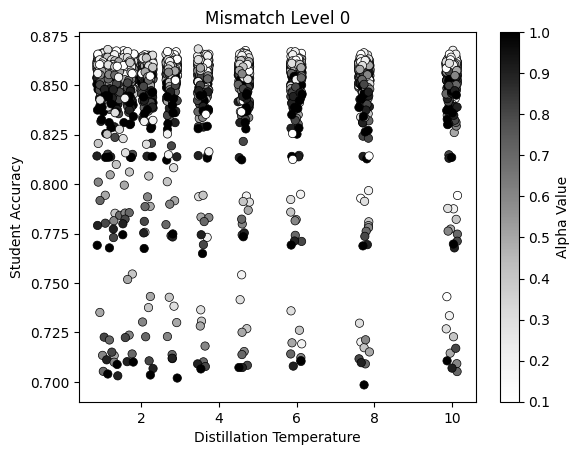

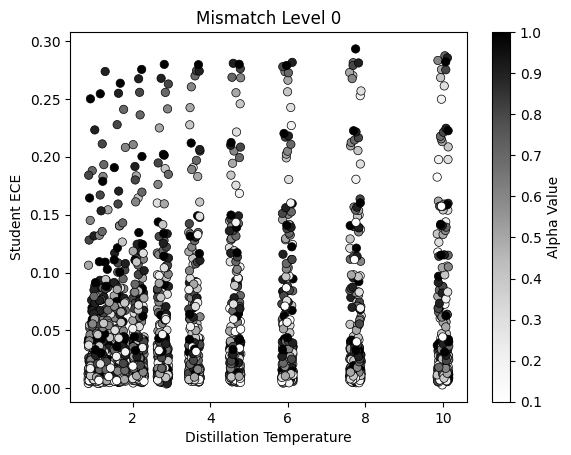

In [ ]:
plot_segment_accs_ByMismatch(0)
plot_segment_ece_ByMismatch(0)

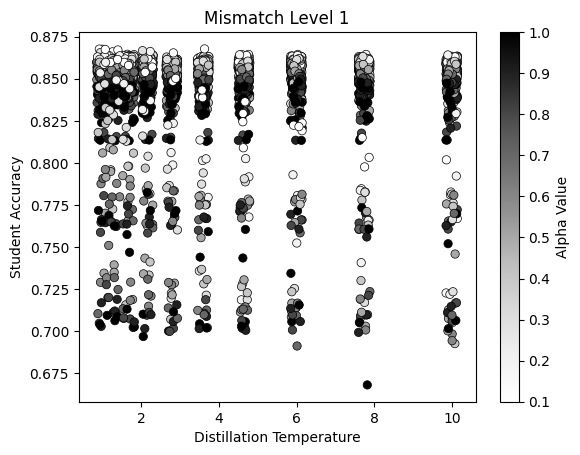

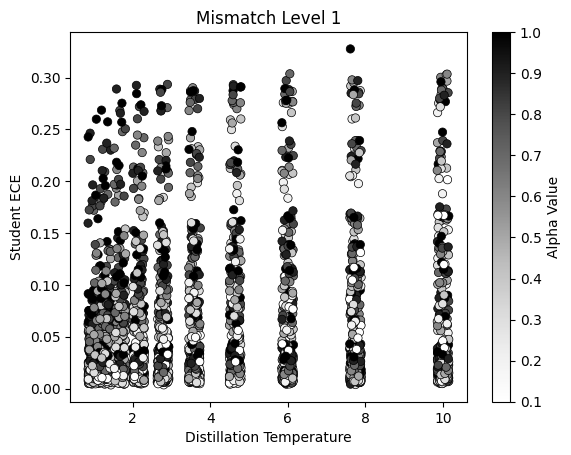

In [ ]:
plot_segment_accs_ByMismatch(1)
plot_segment_ece_ByMismatch(1)

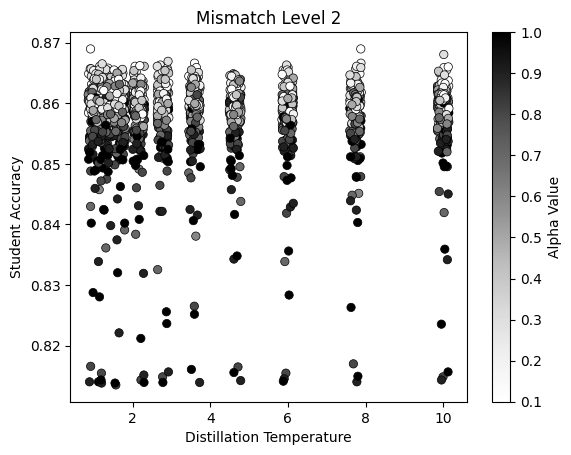

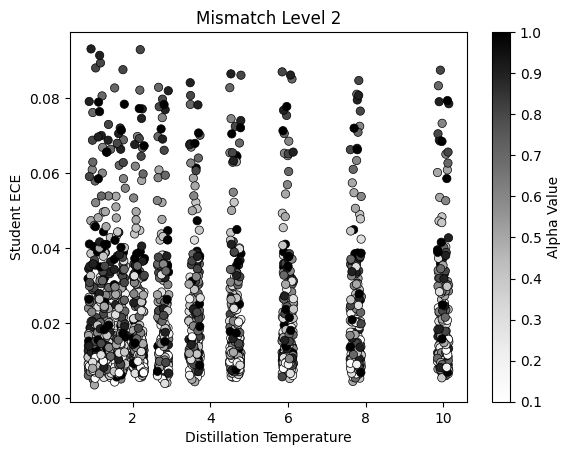

In [ ]:
plot_segment_accs_ByMismatch(2)
plot_segment_ece_ByMismatch(2)

## Accuracy and Calibration Analysis

In [ ]:
pairwise_accuracy_stats_ByMismatch = heterogenous.groupby('mismatch_level')['student_accuracy'].agg(
    min_accuracy ='min',
    max_accuracy='max',
    accuracy_difference =lambda x: x.max() - x.min(),
    mean_accuracy = 'mean',
    standard_deviation_accuracy = 'std'
)
display(pairwise_accuracy_stats_ByMismatch)

,min_accuracy,max_accuracy,accuracy_difference,mean_accuracy,standard_deviation_accuracy
mismatch_level,,,,,
0,0.698434,0.868359,0.169925,0.848704,0.027314
1,0.668032,0.867745,0.199713,0.843840,0.033516
2,0.813492,0.868973,0.055482,0.857552,0.007583


In [ ]:
pairwise_calibration_stats_ByMismatch = heterogenous.groupby('mismatch_level')['student_ece'].agg(
    min_ece ='min',
    max_ece ='max',
    ece_difference = lambda x: x.max() - x.min(),
    mean_ece = 'mean',
    standard_deviation_ece = 'std'
)
pairwise_calibration_stats_ByMismatch

,min_ece,max_ece,ece_difference,mean_ece,standard_deviation_ece
mismatch_level,,,,,
0,0.003005,0.293133,0.290128,0.042465,0.053752
1,0.003486,0.327737,0.324251,0.053470,0.065222
2,0.003545,0.093100,0.089554,0.022685,0.017904


## Optimal Temperature

In [ ]:
df_accs = heterogenous.groupby(['mismatch_level','distill_temperature','alpha'])[['student_accuracy','student_ece']].mean()

def get_optimal_params(group):
    threshold = group['student_accuracy'].max() - 0.01
    candidates = group[group['student_accuracy'] >= threshold]
    return candidates.loc[candidates['student_ece'].idxmin()]

temp = df_accs.reset_index().groupby(['mismatch_level']).apply(get_optimal_params, include_groups=False).reset_index()
display(temp)
min = float(temp[temp['mismatch_level']==0]['distill_temperature'][0])
max = float(temp[temp['mismatch_level']==2]['distill_temperature'][2])
# print(max, min)
sensitivity = (max-min)/2
sensitivity

,mismatch_level,distill_temperature,alpha,student_accuracy,student_ece
0,0,1.000,0.1,0.860921,0.008844
1,1,1.292,0.1,0.860773,0.009443
2,2,1.668,0.1,0.861990,0.008942


0.33399999999999996